# Homework 1
Welcome to Homework 1 of AI

## Part A

In Part 1 you will understand and solve the following concepts

- Iterative Deepening Search(IDS)
- Depth Limited Search (DLS)
- Their pros and cons as compared to DFS, BFS  

In class you have studied 3 Uninformed searching algorithms i.e. Depth First Search, Breath First Search and Uniform Cost Search. In this assignment you will study 2 new searching algorithms. Please go through the document “depth limited and iterative deepening.pdf” and answer the following questions.

### A.1 (10pts)
**Consider the following tree , where “A” is the start state and “L” is the Goal state. Answer the questions that follows**

<img src="graph.png" width=800px>

**Note**: Use alphabetical order to add elements to the frontier.

Write down the sequence in which nodes will be explored if we use:

a)	(2pt) Depth Limited Search Algorithm with limit 3. 

**Your answer**:  
A-C-F-J-B-E-I-H-D-G

b)	(6pt) Iterative Deepening Search Algorithm. 

**Your answer**:

depth 0: A

depth 1: A-C-B 

depth 2: A-C-F-B-E-D

depth 3: A-C-F-J-B-E-I-H-D-G

depth 4: A-C-F-J-B-E-I-N-M-H-L

c)  (2pt) Depth First Search Algorithm. 

**Your answer**:  
A-C-F-J-B-E-I-N-M-H-L

### A.2 (3pts)
Find Time and Space complexity of a), b), c) in the previous question. (Use big O notation)

**Your answer**:

a) Time: O(b^L)   =   O(2^3)
   
   Space: O(b*L)  =   O(6)

b) Time: O(b^d)   =  O(2^4)
   
   Space: O(b*d)  =  O(8)

c) Time: O(b^m)   =  O(2^4)
   
   Space: O(b*m)  =  O(8)

### A.3 (2pts)
What is the advantage of Iterative Deepening Search over Depth First Algorithms? 

**Your answer**:
There are several reasons as to why the IDS is more advantageous over the DFS, they are:
1. The IDS is typically complete (if a soln exists) and optimal.
2. It explores the tree in an iterative manner (gradually iterating through the depth if the goal is not found), meaning it tracks and explores nodes to a certain depth instead of exploring the entire tree.
3. Performs better with a larger search space and the soln's depth is unknown.
4. Combines the benefits of the BFS completeness and optimality, and DFS space complexity.
   Time Complexity: O(b^d)
   Space Complexity: O(b*d)
5. Decreases the possibility of being stuck in a loop as compared to the DFS.

## Part B Word Search [15 pts]
Imagine you have got a grid full of letters – like a word puzzle. Your job is to figure out if the letters of the given word can be constructed from sequentially adjacent cells. The following cell describes the WordSearch problem that you will use later on.

In [18]:
#!pip install pillow
from PIL import Image, ImageDraw, ImageFont

class WordSearch():
    def __init__(self, board):
        
        self.height = len(board)
        self.width = len(board[0])

        self.board = board
    
    def result(self, state):    
        row, col = state
        candidates = [
            
            ("down", (row + 1, col)),    
            ("right", (row, col + 1)),
            ("left", (row, col - 1)),
            ("up", (row - 1, col))
        ]
        result = []
        for action, (r, c) in candidates:
            if 0 <= r < self.height and 0 <= c < self.width:
                result.append((action, (r, c)))
        return result

    # for visualization    
    def output_image(self, solution = None):
        from PIL import Image, ImageDraw
        cell_size = 50
        cell_border = 2

        # Create a blank canvas
        img = Image.new(
            "RGBA",
            (self.width * cell_size, self.height * cell_size),
            "black"
        )
        draw = ImageDraw.Draw(img)

        solution = solution[1] if solution is not None else None
        for i, row in enumerate(self.board):
            for j, col in enumerate(row):

                if solution and (i,j) in solution:
                    fill = (255, 255, 0)
                else:
                    fill = (255, 255, 255)
                # Draw cell
                draw.rectangle(
                    ([(j * cell_size + cell_border, i * cell_size + cell_border),
                      ((j + 1) * cell_size - cell_border, (i + 1) * cell_size - cell_border)]),
                    fill=fill
                )
        font = ImageFont.truetype("Arial.ttf", size=25)
        font.font
        for i, row in enumerate(self.board):
            for j, col in enumerate(row):
                draw.text((j*cell_size+10, i*cell_size+10), self.board[i][j], (20,20,20), font=font)
        display(img)
        #img.save('test.png')

In [19]:
board = [["A","B","C","E"],["S","F","C","S"],["A","D","E","E"]]
wordsearch = WordSearch(board)
wordsearch.result((0,0))

[('down', (1, 0)), ('right', (0, 1))]

### Description:
For example given the following grid of letters
```board = [["A","B","C","E"],["S","F","C","S"],["A","D","E","E"]]```
and the 
```word = 'BCCED'```
Your program should return the following solution:
```solution = (['None', 'right', 'down', 'down', 'left'], [(0, 1), (0, 2), (1, 2), (2, 2), (2, 1)])```

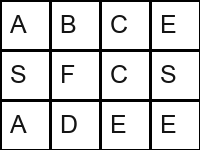

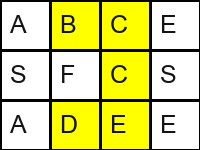

In [20]:
board = [["A","B","C","E"],["S","F","C","S"],["A","D","E","E"]]
wordsearch = WordSearch(board)
word = "BCCED"
wordsearch.output_image() # Print out the board

# The solution in this case is given by the following:
solution = ([None, 'right', 'down', 'down', 'left'], [(0, 1), (0, 2), (1, 2), (2, 2), (2, 1)])
wordsearch.output_image(solution) # Print out the board with solution highlighted

**Use the following functions to define the Node and the frontier**

In [21]:
import sys

class Node():
    def __init__(self, state, parent, action):
        self.state = state
        self.parent = parent # parent of the current node
        self.action = action # action that was taken to reach this node

# Last in first out frontier
class StackFrontier():
    def __init__(self):
        self.frontier = []

    def add(self, node):
        self.frontier.append(node)

    def contains_state(self, state):
        return any(node.state == state for node in self.frontier)

    def empty(self):
        return len(self.frontier) == 0

    def remove(self):
        if self.empty():
            raise Exception("empty frontier")
        else:
            node = self.frontier.pop()
            return node
# First in first out frontier
class QueueFrontier(StackFrontier):

    def remove(self):
        if self.empty():
            raise Exception("empty frontier")
        else:
            node = self.frontier.pop(0)
            return node

In [190]:
# Implemention of 2 get functions to acquire a list of states and a string from the board.
# A function to get the list of states (cells) from a set state to the beginning state (the root) and then reversing the list (start -> set state).
def get_states(board, node):
    cells = []
    while node.parent is not None:
        cells.append(node.state)
        node = node.parent
    cells.append(node.state)
    cells.reverse()
    return cells

# A function to create a sequence of letters (a word) from the board. Meaning, it extracts and concatenates the characters into a string.
def get_string(board, cells):
    string = ""
    for cell in cells:
        i, j = cell
        string += board[i][j]
    return string

In [191]:
class Solution:
    def __init__(self, problem):
        self.problem = problem
        
    def exist(self, word):
        for row in range(self.problem.height):
            for col in range(self.problem.width):
                if self.problem.board[row][col] == word[0]:
                    initial = (row, col)
                    return self.graph_search(initial, word)
                    
        return False

    # Testing whether the current state is the goal state
    def goal_test(self, state, word):
        visited = get_states(self.problem.board, state)
        current_string = get_string(self.problem.board, visited)
        return current_string == word

    def graph_search(self, initial_state, word):
        # Initialize frontier to just the starting position
        start = Node(state = initial_state, parent=None, action=None)
        frontier = StackFrontier()
        frontier.add(start)

        # Initialize an empty explored set
        explored = set()
    
        # Keep looping until solution found
        while True:
            # If nothing left in frontier, then no path
            if frontier.empty():
                raise Exception("no solution")

            # Choose a node from the frontier
            node = frontier.remove()

            visited = get_states(self.problem.board, node)
            current_string = get_string(self.problem.board, visited)

            if not word.startswith(current_string):
                continue

            # Mark node as explored
            explored.add(node.state)

            # If node is the goal, then we have a solution
            if self.goal_test(node, word):
                actions = []
                cells = []
                while node.parent is not None:
                    actions.append(node.action)
                    cells.append(node.state)
                    node = node.parent
                cells.append(start.state)
                actions.append("None")
                actions = actions[::-1]
                cells = cells[::-1]
                solution = (actions, cells)
                return solution, explored
        
            # Add neighbors to frontier
            for action, state in self.problem.result(node.state):
                if not frontier.contains_state(state) and state not in explored:
                    child = Node(state=state, parent=node, action=action)
                    frontier.add(child)

    # A function to print out the solution from the start to the goal
    def print_solution(self, soln):
        actions, cells = soln
        print("Solution =", actions)

### Solution:

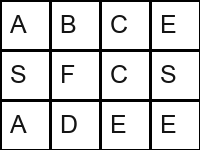

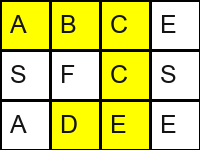

Solution = (['None', 'right', 'right', 'down', 'down', 'left'], [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1)])


In [193]:
board = [["A","B","C","E"],["S","F","C","S"],["A","D","E","E"]]
wordsearch = WordSearch(board)
word = "ABCCED"
wordsearch.output_image()

s = Solution(wordsearch)
sol = s.exist(word)
wordsearch.output_image(sol)
s.print_solution(sol)

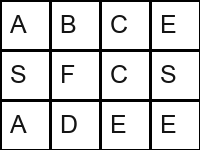

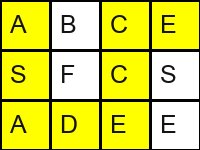

Solution = (['None', 'down', 'down', 'right', 'right', 'up', 'up', 'right'], [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (1, 2), (0, 2), (0, 3)])


In [199]:
board = [["A","B","C","E"],["S","F","C","S"],["A","D","E","E"]]
wordsearch = WordSearch(board)
word = "ASADECCE"
wordsearch.output_image()

s = Solution(wordsearch)
sol = s.exist(word)
wordsearch.output_image(sol)
s.print_solution(sol)

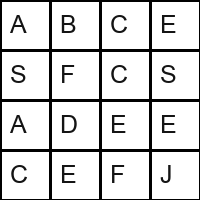

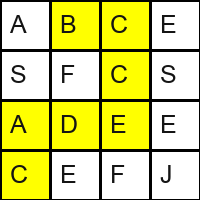

Solution = (['None', 'right', 'down', 'down', 'left', 'left', 'down'], [(0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (3, 0)])


In [195]:
board = [["A","B","C","E"],["S","F","C","S"],["A","D","E","E"], ["C","E","F","J"]]
wordsearch = WordSearch(board)
word = "BCCEDAC"
wordsearch.output_image()

s = Solution(wordsearch)
sol = s.exist(word)
wordsearch.output_image(sol)
s.print_solution(sol)

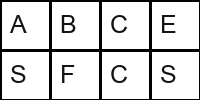

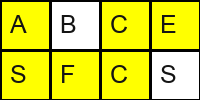

Solution = (['None', 'down', 'right', 'right', 'up', 'right'], [(0, 0), (1, 0), (1, 1), (1, 2), (0, 2), (0, 3)])


In [196]:
board = [["A","B","C","E"],["S","F","C","S"]]
wordsearch = WordSearch(board)
word = "ASFCCE"
wordsearch.output_image()

s = Solution(wordsearch)
sol = s.exist(word)
wordsearch.output_image(sol)
s.print_solution(sol)

### Grading rubric for Question 2
- 7 points: getting correct solution for the board provided above with various word searches
- 8 points: getting correct solution on a larger board with various word searches